Import Libraries

In [43]:
import pandas as pd           # loads pandas library for data manipulation and analysis
import matplotlib.pyplot as plt  # loads matplotlib library for data visualization
import seaborn as sns            # loads seaborn library for statistical data visualization

pd.set_option('display.max_columns', None)  # display all columns in the dataframe

Load the Dataset

In [32]:
df = pd.read_csv(r"C:\Users\Rumeth\Downloads\fertilizer_recommendation.csv")  # loads the dataset from a CSV file 
df.head()  # displays the first five rows 

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


Check Dataset Shape

In [33]:
print(f"Number of rows: {df.shape[0]}")  # prints the number of rows in the dataset
print(f"Number of columns: {df.shape[1]}")  # prints the number of columns in the dataset

Number of rows: 10000
Number of columns: 20


Display Dataset Information

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  str    
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  str    
 12  Crop_Growth_Stage            10000 non-null  str    
 13  Season                      

Check Missing Values

In [35]:
missing_values = df.isnull().sum()  # calculates the number of missing values in each column
print(missing_values)  # prints columns with missing values

Soil_Type                      0
Soil_pH                        0
Soil_Moisture                  0
Organic_Carbon                 0
Electrical_Conductivity        0
Nitrogen_Level                 0
Phosphorus_Level               0
Potassium_Level                0
Temperature                    0
Humidity                       0
Rainfall                       0
Crop_Type                      0
Crop_Growth_Stage              0
Season                         0
Irrigation_Type                0
Previous_Crop                  0
Region                         0
Fertilizer_Used_Last_Season    0
Yield_Last_Season              0
Recommended_Fertilizer         0
dtype: int64


Check Duplicated Values

In [36]:
print(f"Duplicated rows: {df.duplicated().sum()}")  # prints the number of duplicated rows in the dataset

Duplicated rows: 0


Seperate Numerical and Categorical Features

In [53]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['str']).columns.tolist()

print("Numerical Features:" )  
print(numerical_features)  # prints the list of numerical features
print("\nCategorical Features:")  
print(categorical_features)  # prints the list of categorical features

Numerical Features:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season']

Categorical Features:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Recommended_Fertilizer']


Removing the Target Variable from Categorical Features

In [38]:
target = "Recommended_Fertilizer"  # defines the target variable for prediction
categorical_features.remove(target)  # removes the target variable from the list of categorical features
print("Updated Categorical Features:")  # prints the updated list of categorical features
print(categorical_features)  # prints the updated list of categorical features

Updated Categorical Features:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region']


Statistical Summary

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.485728,1.152964,4.50,5.490,6.460,7.4900,8.50
Soil_Moisture,10000.0,35.411531,14.413002,10.00,23.030,35.645,47.6625,60.00
Organic_Carbon,10000.0,0.844731,0.372406,0.20,0.520,0.850,1.1600,1.50
Electrical_Conductivity,10000.0,1.543156,0.839514,0.10,0.820,1.530,2.2700,3.00
Nitrogen_Level,10000.0,88.995000,40.336674,20.00,54.000,89.000,124.0000,159.00
Phosphorus_Level,10000.0,48.965100,23.195588,10.00,29.000,49.000,69.0000,89.00
Potassium_Level,10000.0,64.147000,31.867211,10.00,37.000,64.000,92.0000,119.00
Temperature,10000.0,25.058906,8.601550,10.00,17.580,25.085,32.5025,40.00
Humidity,10000.0,60.093727,17.386120,30.01,44.925,60.345,75.4200,89.99
Rainfall,10000.0,1588.085798,810.992404,200.08,874.780,1594.295,2283.7825,2999.98


In [52]:
df.describe(include='str').T 

,count,unique,top,freq
Soil_Type,10000,4,Sandy,2536
Crop_Type,10000,7,Wheat,1467
Crop_Growth_Stage,10000,4,Harvest,2547
Season,10000,3,Kharif,3363
Irrigation_Type,10000,4,Sprinkler,2531
Previous_Crop,10000,7,Cotton,1492
Region,10000,5,West,2026
Recommended_Fertilizer,10000,7,Urea,3101


Target Variable Distribution

In [41]:
target_counts = df[target].value_counts()
print(target_counts)

target_percentage = df[target].value_counts(normalize=True) * 100
print(target_percentage.round(2))

Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64
Recommended_Fertilizer
Urea             31.01
DAP              29.20
MOP              14.08
Compost           9.96
Zinc Sulphate     7.52
NPK               6.41
SSP               1.82
Name: proportion, dtype: float64


Plot for the distribution of the target variable

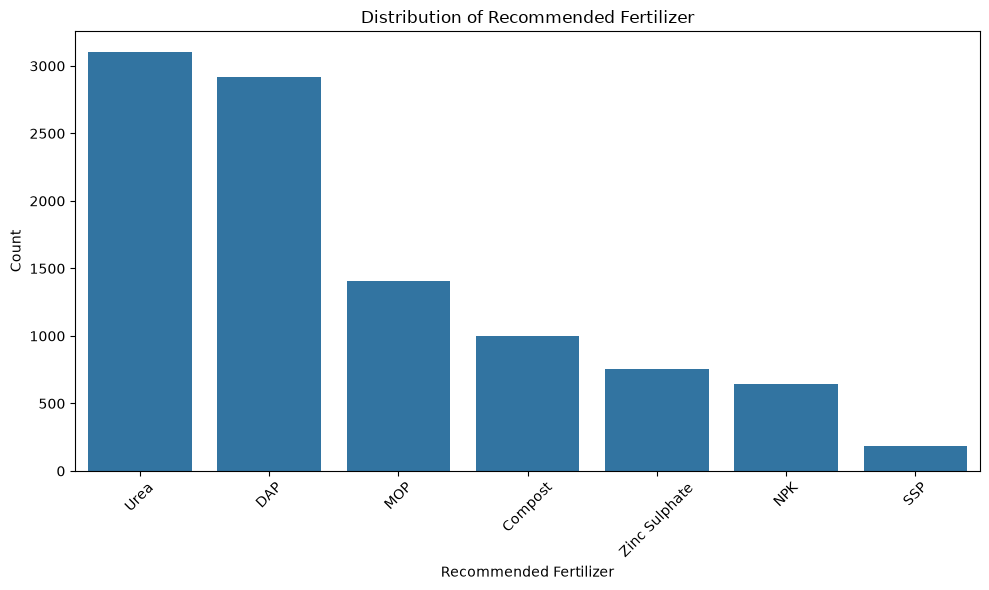

In [44]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x=target, order=df[target].value_counts().index)

plt.title('Distribution of Recommended Fertilizer')
plt.xlabel('Recommended Fertilizer')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Plot for the Distribution of Numerical Features

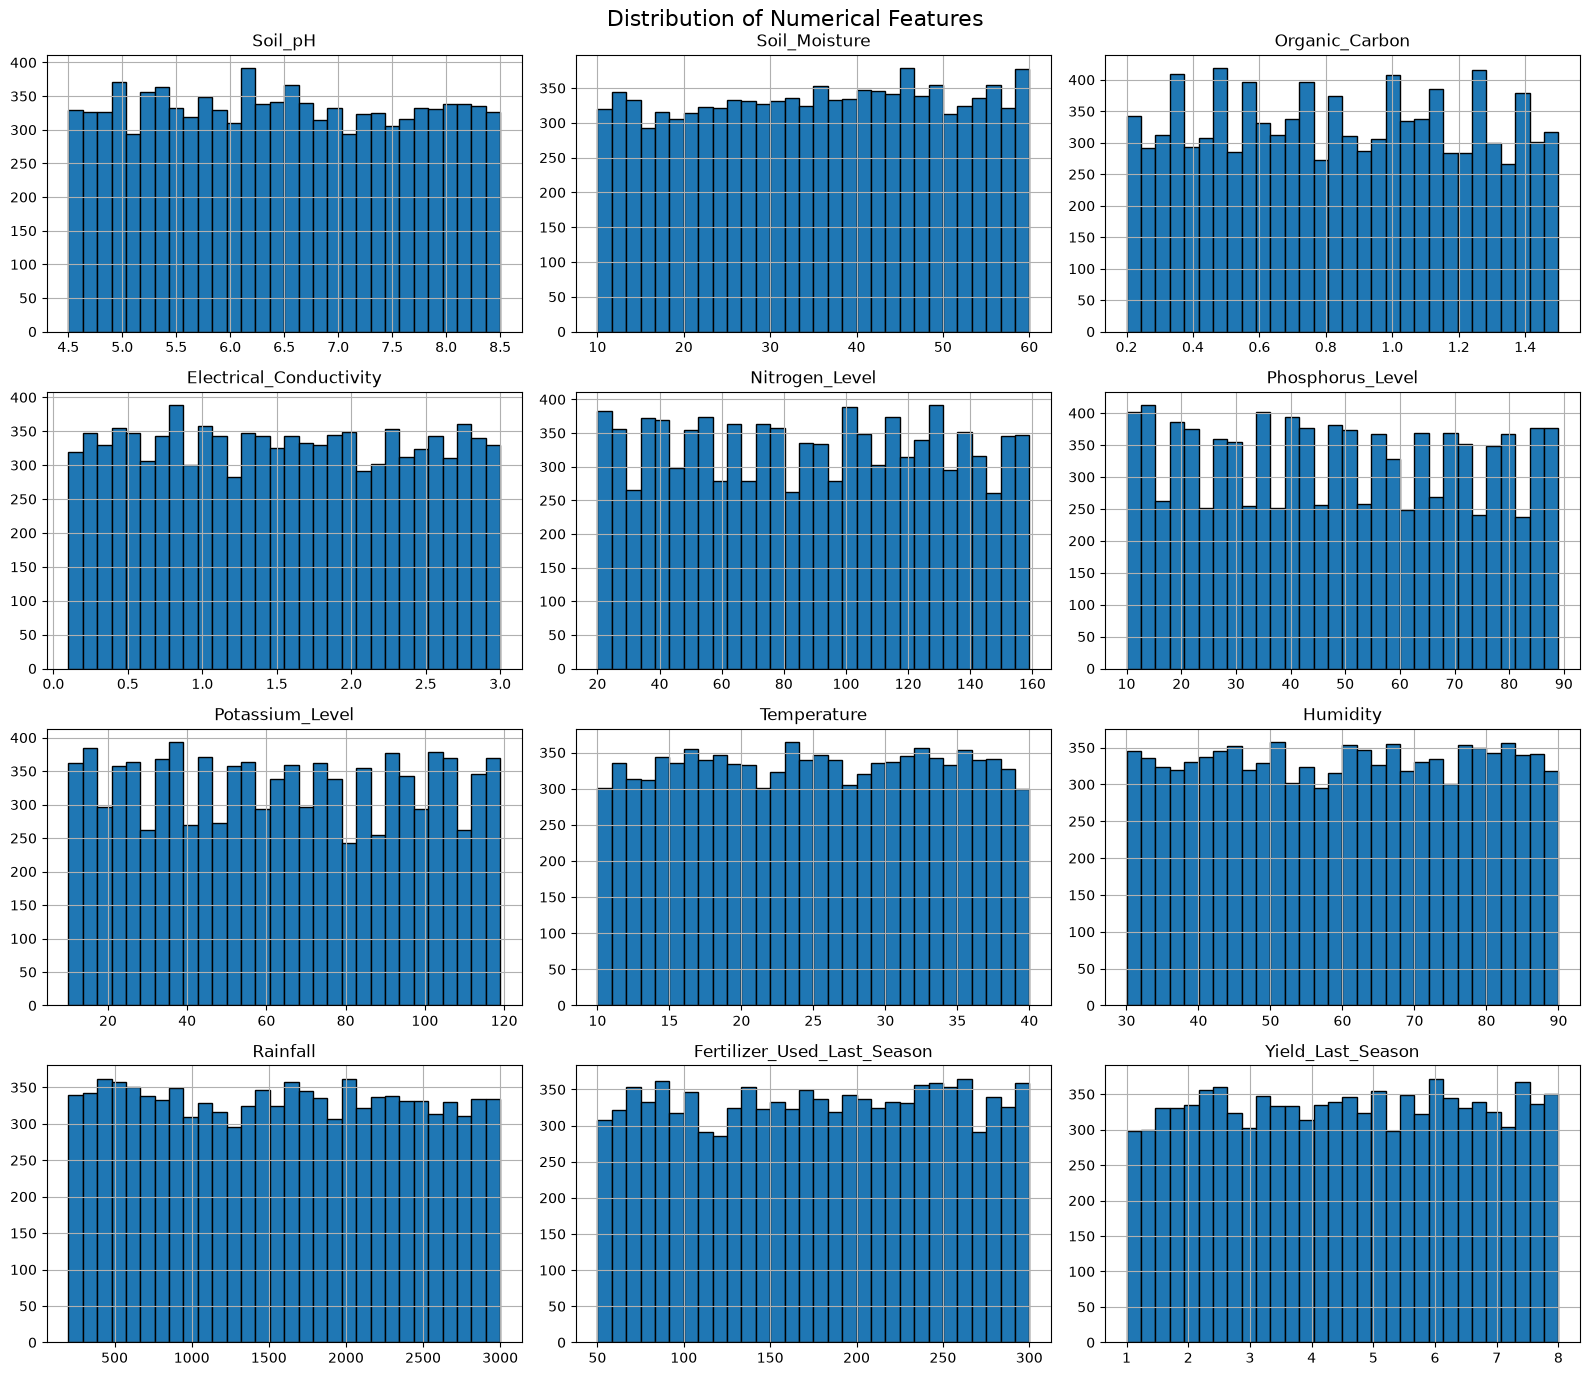

In [45]:
df[numerical_features].hist(
    figsize=(16,14),
    bins=30,
    edgecolor='black'
)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

Boxplot of Numerical Features

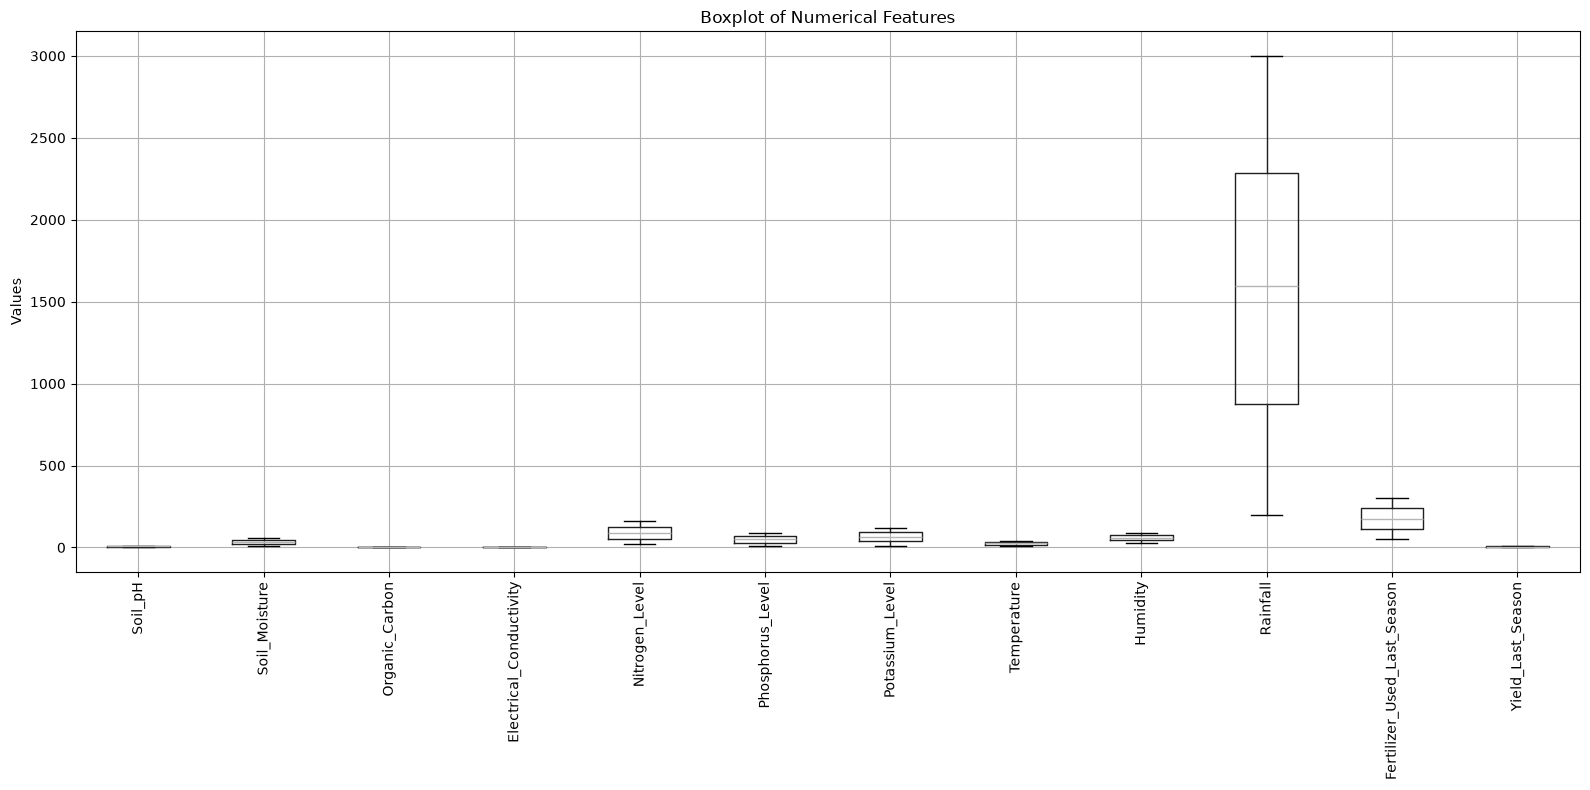

In [46]:
plt.figure(figsize=(16, 8))

df[numerical_features].boxplot()

plt.title('Boxplot of Numerical Features')
plt.xticks(rotation=90)
plt.ylabel('Values')

plt.tight_layout()
plt.show()

Correlation Matrix

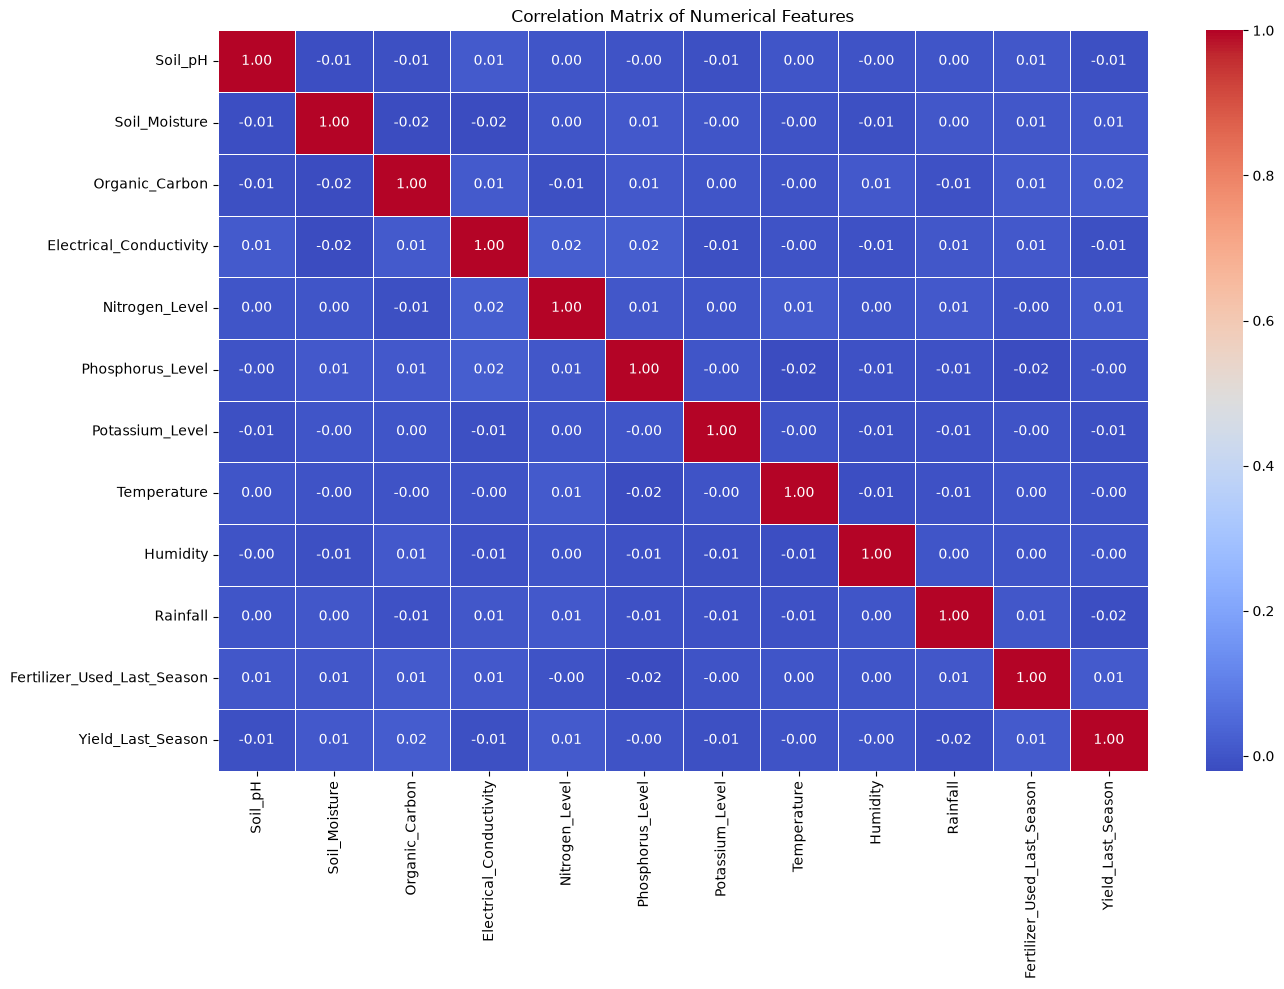

In [47]:
correlation_matrix = df[numerical_features].corr()

correlation_matrix

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features')

plt.tight_layout()
plt.show()

Distribution of Categorical Features

In [48]:
for column in categorical_features:
    print(f"\n{'=' * 50}")
    print(f"{column}")
    print(f"Unique values: {df[column].nunique()}")
    print(df[column].value_counts())


Soil_Type
Unique values: 4
Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64

Crop_Type
Unique values: 7
Crop_Type
Wheat        1467
Tomato       1451
Rice         1429
Sugarcane    1428
Potato       1425
Maize        1424
Cotton       1376
Name: count, dtype: int64

Crop_Growth_Stage
Unique values: 4
Crop_Growth_Stage
Harvest       2547
Vegetative    2524
Flowering     2499
Sowing        2430
Name: count, dtype: int64

Season
Unique values: 3
Season
Kharif    3363
Rabi      3337
Zaid      3300
Name: count, dtype: int64

Irrigation_Type
Unique values: 4
Irrigation_Type
Sprinkler    2531
Rainfed      2526
Drip         2499
Canal        2444
Name: count, dtype: int64

Previous_Crop
Unique values: 7
Previous_Crop
Cotton       1492
Maize        1458
Rice         1446
Sugarcane    1433
Wheat        1418
Potato       1387
Tomato       1366
Name: count, dtype: int64

Region
Unique values: 5
Region
West       2026
North      2012
East       1998
South

Plot for the Recommended Fertilizer by Crop Type

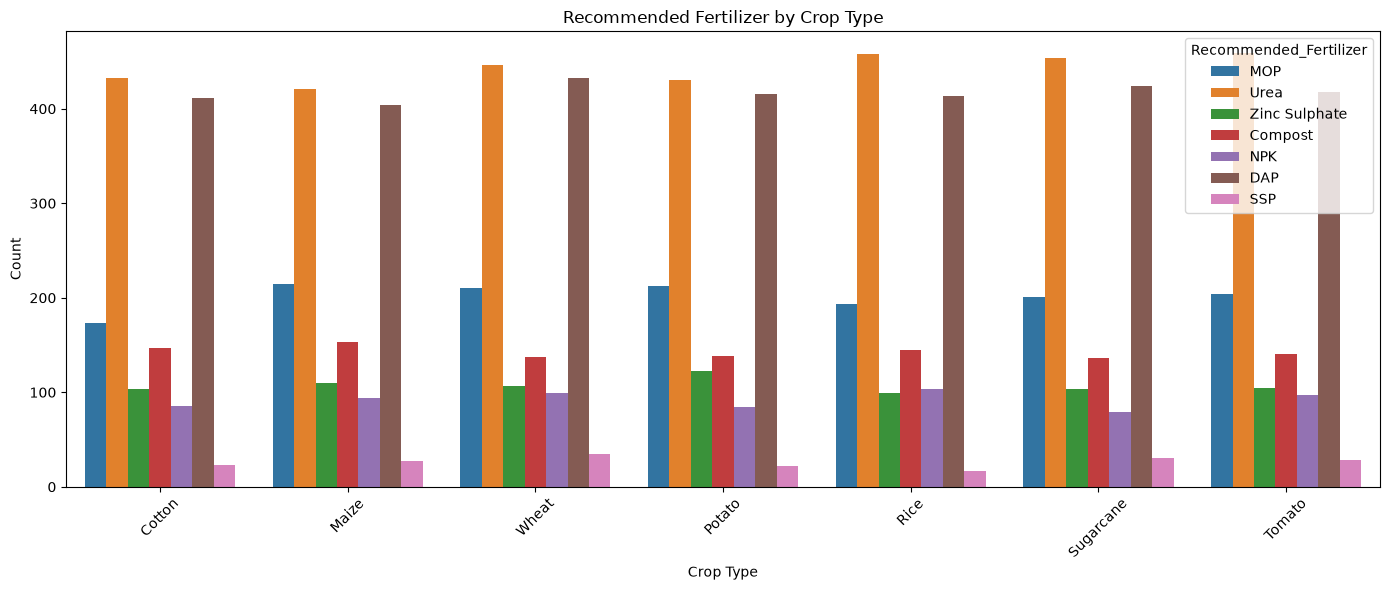

In [49]:
plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x='Crop_Type',
    hue='Recommended_Fertilizer'
)

plt.title('Recommended Fertilizer by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Plot for the Recommended Fertilizer by Soil Type

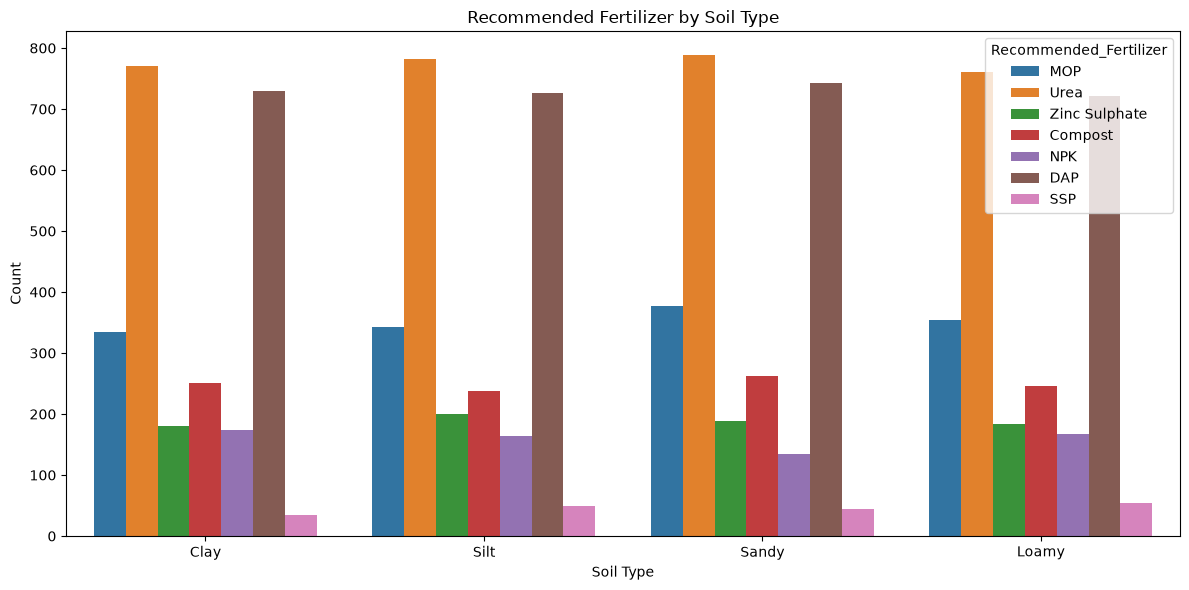

In [50]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='Soil_Type',
    hue='Recommended_Fertilizer'
)

plt.title('Recommended Fertilizer by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

Plot for the N,P,K Levels by Recommended Fertlizer

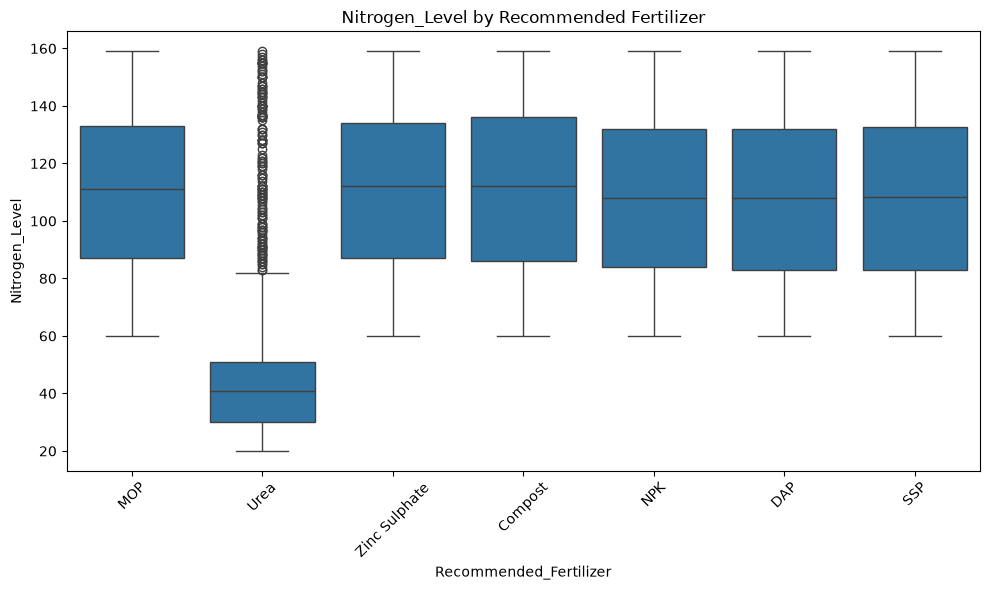

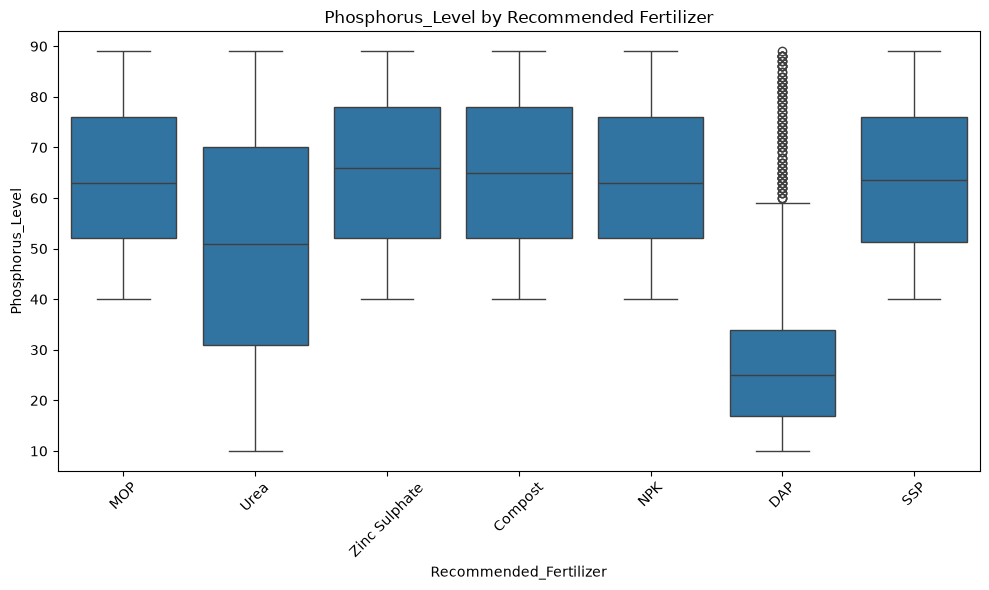

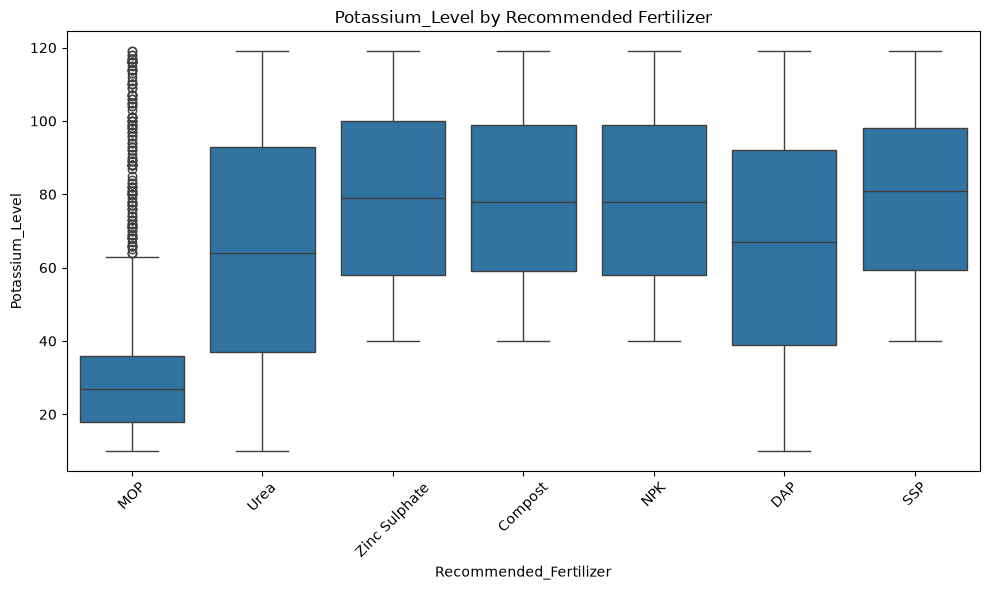

In [51]:
npk_features = [
    'Nitrogen_Level',
    'Phosphorus_Level',
    'Potassium_Level'
]

for feature in npk_features:
    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=df,
        x='Recommended_Fertilizer',
        y=feature
    )

    plt.title(f'{feature} by Recommended Fertilizer')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()